### Comparing centrolign mutation rate in the array to the flanks 

In [4]:
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

#### Investigate missingness and proportion aligned for the MC vcf

In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────

VCF_DIR  = "/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/flanking_50kb"
BED_DIR  = "/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/per_sample_maf_beds"
CHROMS   = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]
FLANKS_BED = "/private/groups/patenlab/mira/centrolign/annotations/chm13/per_chrom/work/chm13v2.0.labels.as_hor.all_chrs.50kb_flanks.bed"

In [6]:
# ── Helper functions for upstream/downstream split ────────────────────────────

def load_flank_intervals(flanks_bed):
    """
    Read CHM13 flanks BED (2 entries per chrom: upstream then downstream by coord order).
    Returns {chrom: {"upstream": (start, end), "downstream": (start, end)}}
    """
    intervals = {}
    seen = defaultdict(int)
    with open(flanks_bed) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            fields = line.split("\t")
            chrom, start, end = fields[0], int(fields[1]), int(fields[2])
            label = "upstream" if seen[chrom] == 0 else "downstream"
            intervals.setdefault(chrom, {})[label] = (start, end)
            seen[chrom] += 1
    return intervals


def get_flank(pos_0based, chrom, flank_intervals):
    """
    Returns 'upstream', 'downstream', or None.
    pos_0based: VCF POS converted to 0-based (vcf_pos - 1).
    """
    if chrom not in flank_intervals:
        return None
    for flank, (start, end) in flank_intervals[chrom].items():
        if start <= pos_0based < end:
            return flank
    return None


def load_bed_total_bases_split(bed_dir, chroms):
    """
    Reads *.upstream.bed and *.downstream.bed files.
    Returns dict: (hap_id, chrom, flank) -> total_bases
    """
    from pathlib import Path
    totals = defaultdict(int)
    chroms_set = set(chroms)
    for flank in ("upstream", "downstream"):
        for bed_path in Path(bed_dir).glob(f"*.{flank}.bed"):
            hap_id = bed_path.name.replace(f".{flank}.bed", "")
            with open(bed_path) as f:
                for line in f:
                    if line.startswith("#") or not line.strip():
                        continue
                    fields = line.split("\t")
                    chrom, start, end = fields[0], int(fields[1]), int(fields[2])
                    if chrom in chroms_set:
                        totals[(hap_id, chrom, flank)] += (end - start)
    return totals

def open_vcf(path):
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path)


def get_vcf_samples(vcf_path):
    with open_vcf(vcf_path) as f:
        for line in f:
            if line.startswith("#CHROM"):
                return line.strip().split("\t")[9:]
    return []


In [32]:
# ── Main calculation: upstream / downstream split ─────────────────────────────

records_split = defaultdict(lambda: {"snvs": 0, "indels": 0, "deleted_bases": 0, "missing": 0, "total_ref_bases": 0})

# Load BED total bases split by flank
print("Loading BED files...")
bed_totals_split = load_bed_total_bases_split(BED_DIR, CHROMS)
for (hap_id, chrom, flank), bases in bed_totals_split.items():
    records_split[(hap_id, chrom, flank)]["total_ref_bases"] += bases

# Load CHM13 flank intervals to classify VCF variant positions
flank_intervals = load_flank_intervals(FLANKS_BED)

# Stream VCFs
for chrom in CHROMS:
    vcf_path = os.path.join(VCF_DIR, f"{chrom}_flanking_50kb.vcf.gz")
    if not os.path.exists(vcf_path):
        print(f"  Skipping {chrom} — VCF not found")
        continue
    print(f"  Processing {chrom}...")

    chrom_sample_list = get_vcf_samples(vcf_path)

    with open_vcf(vcf_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields  = line.rstrip("\n").split("\t")
            pos_0   = int(fields[1]) - 1   # VCF is 1-based → convert to 0-based
            ref     = fields[3]
            alts    = fields[4].split(",")
            fmt     = fields[8].split(":")
            gt_idx  = fmt.index("GT") if "GT" in fmt else 0
            ref_len = len(ref)

            flank = get_flank(pos_0, chrom, flank_intervals)
            if flank is None:
                continue   # position not in either annotated flank — skip

            for i, samp in enumerate(chrom_sample_list):
                gt_field = fields[9 + i].split(":")[gt_idx]
                alleles  = gt_field.replace("|", "/").split("/")

                for hap_idx, allele in enumerate(alleles):
                    hap_id = f"{samp}.{hap_idx + 1}"
                    key    = (hap_id, chrom, flank)

                    if allele == ".":
                        records_split[key]["missing"] += 1
                        continue

                    if allele == "0":
                        continue

                    alt_seq = alts[int(allele) - 1]
                    alt_len = len(alt_seq)

                    if ref_len == 1 and alt_len == 1:
                        records_split[key]["snvs"] += 1
                    elif abs(ref_len - alt_len) < 50:
                        records_split[key]["indels"] += 1

                    if alt_len < ref_len:
                        records_split[key]["deleted_bases"] += (ref_len - alt_len)

# ── Build results dataframe ───────────────────────────────────────────────────

rows = []
for (hap_id, chrom, flank), vals in records_split.items():
    total   = vals["total_ref_bases"]
    deleted = vals["deleted_bases"]
    snvs    = vals["snvs"]
    aligned = max(total - deleted, 0)
    rows.append({
        "sample":          hap_id.rsplit(".", 1)[0],
        "haplotype":       hap_id,
        "chrom":           chrom,
        "flank":           flank,
        "total_ref_bases": total,
        "deleted_bases":   deleted,
        "aligned_bases":   aligned,
        "snvs":            snvs,
        "indels":          vals["indels"],
        "missing":         vals["missing"],
        "snv_rate":        snvs / aligned if aligned > 0 else np.nan,
        "indel_rate":      vals["indels"] / aligned if aligned > 0 else np.nan,
    })

df_split = pd.DataFrame(rows)
print(df_split.head(20))

Loading BED files...
  Processing chr1...
  Processing chr2...
  Processing chr3...
  Processing chr4...
  Processing chr5...
  Processing chr6...
  Processing chr7...
  Processing chr8...
  Processing chr9...
  Processing chr10...
  Processing chr11...
  Processing chr12...
  Processing chr13...
  Processing chr14...
  Processing chr15...
  Processing chr16...
  Processing chr17...
  Processing chr18...
  Processing chr19...
  Processing chr20...
  Processing chr21...
  Processing chr22...
  Processing chrX...
  Processing chrY...
     sample  haplotype  chrom     flank  total_ref_bases  deleted_bases  \
0   HG01361  HG01361.1  chr10  upstream            50000              3   
1   HG01361  HG01361.1  chr11  upstream            50000             17   
2   HG01361  HG01361.1  chr12  upstream            49217            519   
3   HG01361  HG01361.1  chr13  upstream            49976            180   
4   HG01361  HG01361.1  chr15  upstream            50000             21   
5   HG01361 

In [29]:
### Get total number of variants relative to CHM13 

import subprocess

plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

flank_intervals = load_flank_intervals(FLANKS_BED)

rows = []
for chrom in plot_chroms:
    vcf_path = os.path.join(VCF_DIR, f"{chrom}_flanking_50kb.vcf.gz")
    if not os.path.exists(vcf_path) or chrom not in flank_intervals:
        continue
    for flank, (start, end) in flank_intervals[chrom].items():
        # bcftools region is 1-based inclusive: start+1 to end
        region = f"{chrom}:{start+1}-{end}"
        result = subprocess.run(
            f"bcftools view -H -r {region} {vcf_path} | wc -l",
            shell=True, capture_output=True, text=True
        )
        rows.append({"chrom": chrom, "flank": flank, "n_variants": int(result.stdout.strip())})

geno_split_df = pd.DataFrame(rows)
print(geno_split_df.to_string())



    chrom       flank  n_variants
0    chr1    upstream         415
1    chr1  downstream        1151
2    chr2    upstream        1234
3    chr2  downstream         705
4    chr3    upstream        1182
5    chr3  downstream        1164
6    chr4    upstream         158
7    chr4  downstream         544
8    chr5    upstream        1352
9    chr5  downstream        2204
10   chr6    upstream        1116
11   chr6  downstream        2640
12   chr7    upstream        2152
13   chr7  downstream        1668
14   chr8    upstream        1110
15   chr8  downstream        1093
16   chr9    upstream        1279
17   chr9  downstream        1066
18  chr10    upstream        2354
19  chr10  downstream        1181
20  chr11    upstream        2394
21  chr11  downstream        1699
22  chr12    upstream        2231
23  chr12  downstream        1321
24  chr13    upstream        2714
25  chr13  downstream        1668
26  chr14    upstream        1797
27  chr14  downstream        1529
28  chr15    u

In [33]:
df_split.head()

,sample,haplotype,chrom,flank,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate,indel_rate
0,HG01361,HG01361.1,chr10,upstream,50000,3,49997,69,5,0,0.001380,0.000100
1,HG01361,HG01361.1,chr11,upstream,50000,17,49983,128,12,0,0.002561,0.000240
2,HG01361,HG01361.1,chr12,upstream,49217,519,48698,119,12,8,0.002444,0.000246
3,HG01361,HG01361.1,chr13,upstream,49976,180,49796,54,28,0,0.001084,0.000562
4,HG01361,HG01361.1,chr15,upstream,50000,21,49979,49,19,0,0.000980,0.000380


In [34]:
## Add proportion of bases aligned and proportion of genotypes missing 

df_split["prop_aligned"] = df_split["aligned_bases"] / 50_000
df_split = df_split.merge(geno_split_df, on=["chrom", "flank"], how="left")
df_split["prop_missing"] = df_split["missing"] / df_split["n_variants"]

df_split.head()


,sample,haplotype,chrom,flank,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate,indel_rate,prop_aligned,n_variants,prop_missing
0,HG01361,HG01361.1,chr10,upstream,50000,3,49997,69,5,0,0.001380,0.000100,0.99994,2354.0,0.000000
1,HG01361,HG01361.1,chr11,upstream,50000,17,49983,128,12,0,0.002561,0.000240,0.99966,2394.0,0.000000
2,HG01361,HG01361.1,chr12,upstream,49217,519,48698,119,12,8,0.002444,0.000246,0.97396,2231.0,0.003586
3,HG01361,HG01361.1,chr13,upstream,49976,180,49796,54,28,0,0.001084,0.000562,0.99592,2714.0,0.000000
4,HG01361,HG01361.1,chr15,upstream,50000,21,49979,49,19,0,0.000980,0.000380,0.99958,2634.0,0.000000


In [35]:
# Sanity check
mask = (
    (df_split["total_ref_bases"] == 0) &
    (
        (df_split["deleted_bases"] > 0) |
        (df_split["snvs"] > 0) |
        (df_split["indels"] > 0)
    )
)
print(df_split[mask].to_string())


Empty DataFrame
Columns: [sample, haplotype, chrom, flank, total_ref_bases, deleted_bases, aligned_bases, snvs, indels, missing, snv_rate, indel_rate, prop_aligned, n_variants, prop_missing]
Index: []


In [18]:
df_split.head()

,sample,haplotype,chrom,flank,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate,indel_rate
0,HG01361,HG01361.1,chr10,upstream,50000,3,49997,69,5,0,0.001380,0.000100
1,HG01361,HG01361.1,chr11,upstream,50000,17,49983,128,12,0,0.002561,0.000240
2,HG01361,HG01361.1,chr12,upstream,49217,519,48698,119,12,8,0.002444,0.000246
3,HG01361,HG01361.1,chr13,upstream,49976,180,49796,54,28,0,0.001084,0.000562
4,HG01361,HG01361.1,chr15,upstream,50000,21,49979,49,19,0,0.000980,0.000380


In [ ]:
# Sanity check
df_split[df_split["total_ref_bases"]>50000]

,sample,haplotype,chrom,flank,total_ref_bases,deleted_bases,aligned_bases,snvs,indels,missing,snv_rate,indel_rate


In [36]:
print(df_split.nlargest(20, "snv_rate").to_string())


       sample  haplotype chrom     flank  total_ref_bases  deleted_bases  aligned_bases  snvs  indels  missing  snv_rate  indel_rate  prop_aligned  n_variants  prop_missing
5062  HG01081  HG01081.2  chr2  upstream             5483            461           5022   178     383      511  0.035444    0.076264       0.10044      1234.0        0.4141
87    HG02071  HG02071.1  chr2  upstream             5483            461           5022   177     383      511  0.035245    0.076264       0.10044      1234.0        0.4141
206   HG02738  HG02738.2  chr2  upstream             5483            461           5022   177     383      511  0.035245    0.076264       0.10044      1234.0        0.4141
317   NA18940  NA18940.2  chr2  upstream             5483            461           5022   177     383      511  0.035245    0.076264       0.10044      1234.0        0.4141
534   NA18960  NA18960.2  chr2  upstream             5483            461           5022   177     383      511  0.035245    0.076264   

##### Check proportion aligned per chrom

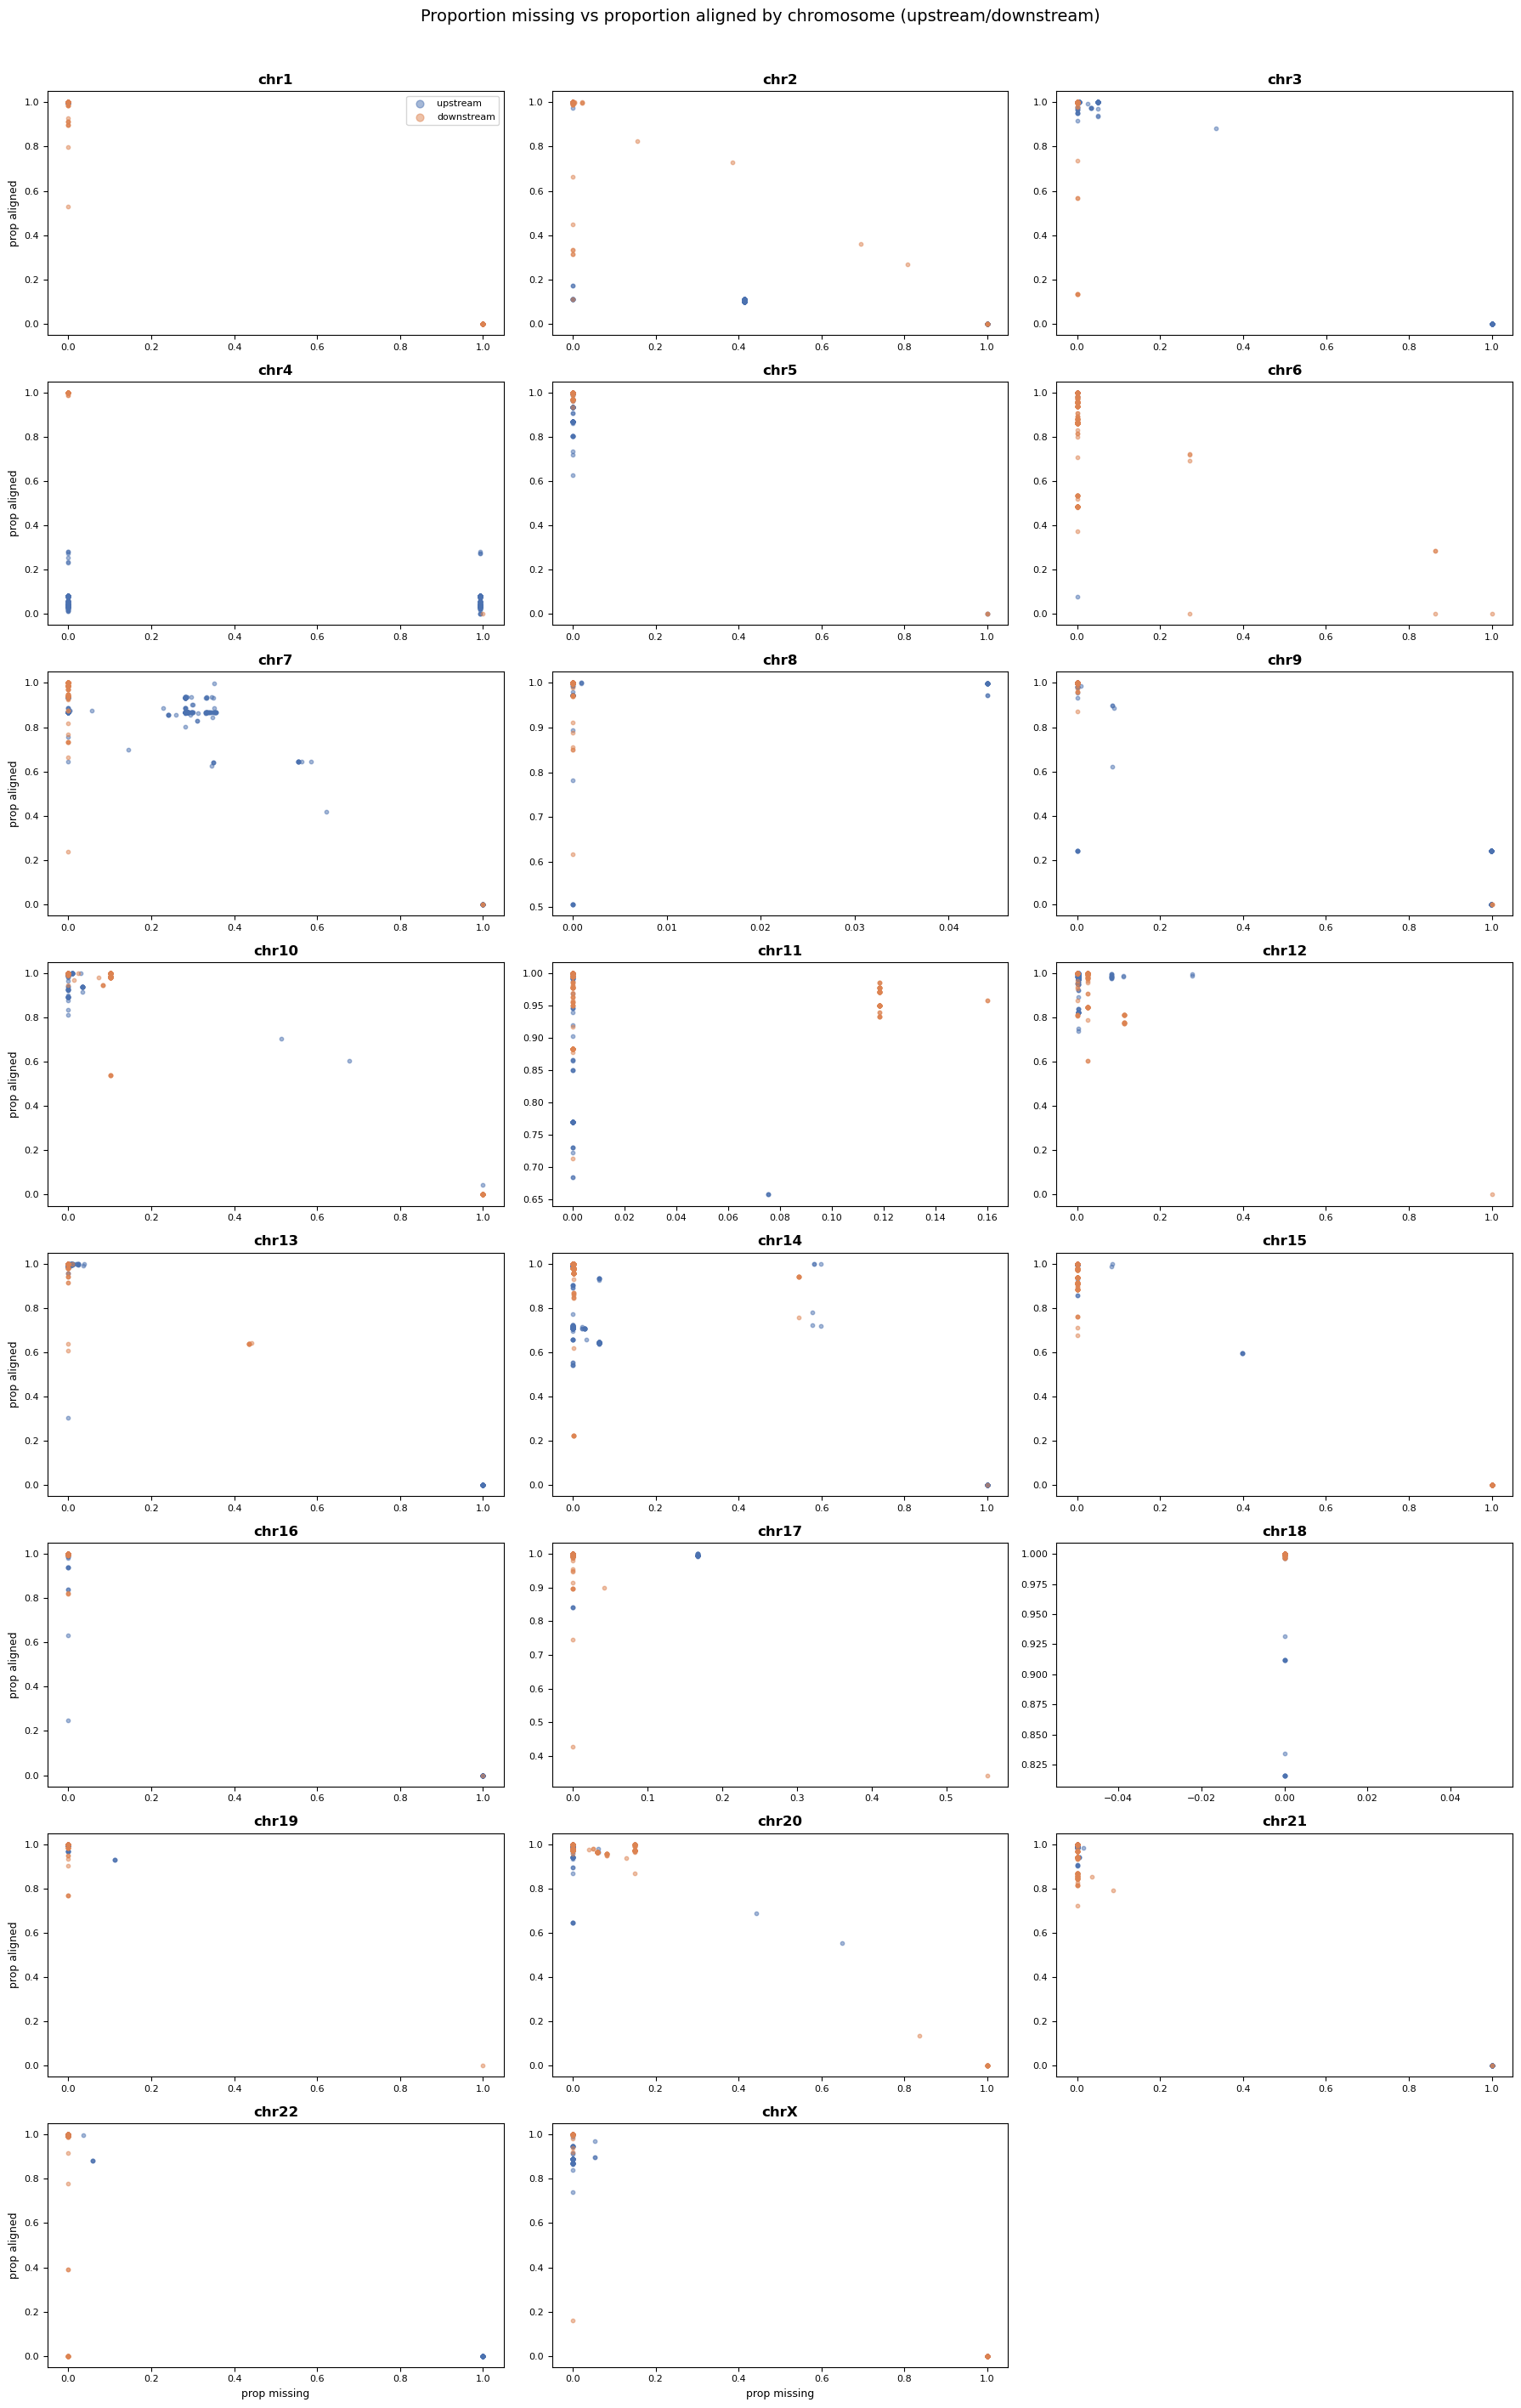

In [37]:
plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]

ncols = 3
nrows = int(np.ceil(len(plot_chroms) / ncols))

palette = {"upstream": "#4C72B0", "downstream": "#DD8452"}

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for i, chrom in enumerate(plot_chroms):
    ax = axes[i]
    for flank, color in palette.items():
        data = df_split[
            (df_split["chrom"] == chrom) & (df_split["flank"] == flank)
        ].dropna(subset=["prop_missing", "prop_aligned"])
        ax.scatter(data["prop_missing"], data["prop_aligned"],
                   alpha=0.5, s=10, color=color, label=flank)
    ax.set_title(chrom, fontsize=12, fontweight="bold")
    ax.set_xlabel("prop missing" if i >= (nrows - 1) * ncols else "", fontsize=9)
    ax.set_ylabel("prop aligned" if i % ncols == 0 else "", fontsize=9)
    ax.tick_params(labelsize=8)

for j in range(len(plot_chroms), len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8, markerscale=2)
plt.suptitle("Proportion missing vs proportion aligned by chromosome (upstream/downstream)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [38]:
### Filter samples with less than 50% aligned or more than 50% missing 
df_split_filt = df_split[
    (df_split["prop_missing"] < 0.5) & (df_split["prop_aligned"] >= 0.5)
].copy()

print(f"Rows before: {len(df_split)}, after: {len(df_split_filt)}")

Rows before: 21149, after: 18121


In [47]:
# ── Compute per-window prop_aligned and prop_missing ─────────────────────────

WINDOW_SIZE = 1000   # 1 kb windows
FLANK_SIZE  = 50000  # 50 kb flanks

def compute_window_stats(bed_dir, vcf_dir, flank_intervals, chroms, window_size=1000):
    """
    For each (chrom, flank, window), compute:
      - aligned_count : number of haplotypes with any aligned bases in window
      - n_haps        : total haplotype bed files for that flank
      - missing_count : total missing allele calls across variants in window
      - n_genotypes   : total allele calls (n_samples * 2) across variants in window
    """
    from pathlib import Path
    chroms_set = set(chroms)

    # Initialise window arrays
    win_data = {}
    for chrom, flanks in flank_intervals.items():
        if chrom not in chroms_set:
            continue
        for flank, (start, end) in flanks.items():
            n_win = int(np.ceil((end - start) / window_size))
            win_data[(chrom, flank)] = {
                "start":         start,
                "n_windows":     n_win,
                "aligned_count": np.zeros(n_win),
                "n_haps":        0,
                "missing_count": np.zeros(n_win),
                "n_genotypes":   np.zeros(n_win),
            }

    # ── BED files → prop_aligned ──────────────────────────────────────────────
    for flank in ("upstream", "downstream"):
        bed_files = list(Path(bed_dir).glob(f"*.{flank}.bed"))
        n_haps = len(bed_files)
        for chrom in chroms_set:
            if (chrom, flank) in win_data:
                win_data[(chrom, flank)]["n_haps"] = n_haps

        for bed_path in bed_files:
            coverage = {}   # key -> bool array
            with open(bed_path) as fh:
                for line in fh:
                    if line.startswith("#") or not line.strip():
                        continue
                    fields  = line.split("\t")
                    b_chrom = fields[0]
                    key     = (b_chrom, flank)
                    if key not in win_data:
                        continue
                    b_start, b_end = int(fields[1]), int(fields[2])
                    if key not in coverage:
                        coverage[key] = np.zeros(win_data[key]["n_windows"], dtype=bool)
                    reg_start = win_data[key]["start"]
                    n_win     = win_data[key]["n_windows"]
                    first_w   = max(0, (b_start - reg_start) // window_size)
                    last_w    = min(n_win - 1, (b_end - 1 - reg_start) // window_size)
                    if last_w >= first_w:
                        coverage[key][first_w : last_w + 1] = True
            for key, cov in coverage.items():
                win_data[key]["aligned_count"] += cov.astype(int)

    # ── VCF files → prop_missing ──────────────────────────────────────────────
    for chrom in chroms:
        vcf_path = os.path.join(vcf_dir, f"{chrom}_flanking_50kb.vcf.gz")
        if not os.path.exists(vcf_path):
            continue
        sample_list = get_vcf_samples(vcf_path)
        n_samples   = len(sample_list)
        with open_vcf(vcf_path) as fh:
            for line in fh:
                if line.startswith("#"):
                    continue
                fields  = line.rstrip("\n").split("\t")
                pos_0   = int(fields[1]) - 1
                fmt     = fields[8].split(":")
                gt_idx  = fmt.index("GT") if "GT" in fmt else 0
                flank   = get_flank(pos_0, chrom, flank_intervals)
                if flank is None:
                    continue
                key = (chrom, flank)
                if key not in win_data:
                    continue
                win_idx = (pos_0 - win_data[key]["start"]) // window_size
                if win_idx < 0 or win_idx >= win_data[key]["n_windows"]:
                    continue
                n_missing = 0
                for i in range(n_samples):
                    gt_field = fields[9 + i].split(":")[gt_idx]
                    n_missing += sum(1 for a in gt_field.replace("|", "/").split("/") if a == ".")
                win_data[key]["missing_count"][win_idx] += n_missing
                win_data[key]["n_genotypes"][win_idx]   += n_samples * 2

    return win_data


print("Computing per-window statistics...")
win_data = compute_window_stats(BED_DIR, VCF_DIR, flank_intervals, CHROMS, WINDOW_SIZE)
print("Done.")

Computing per-window statistics...
Done.


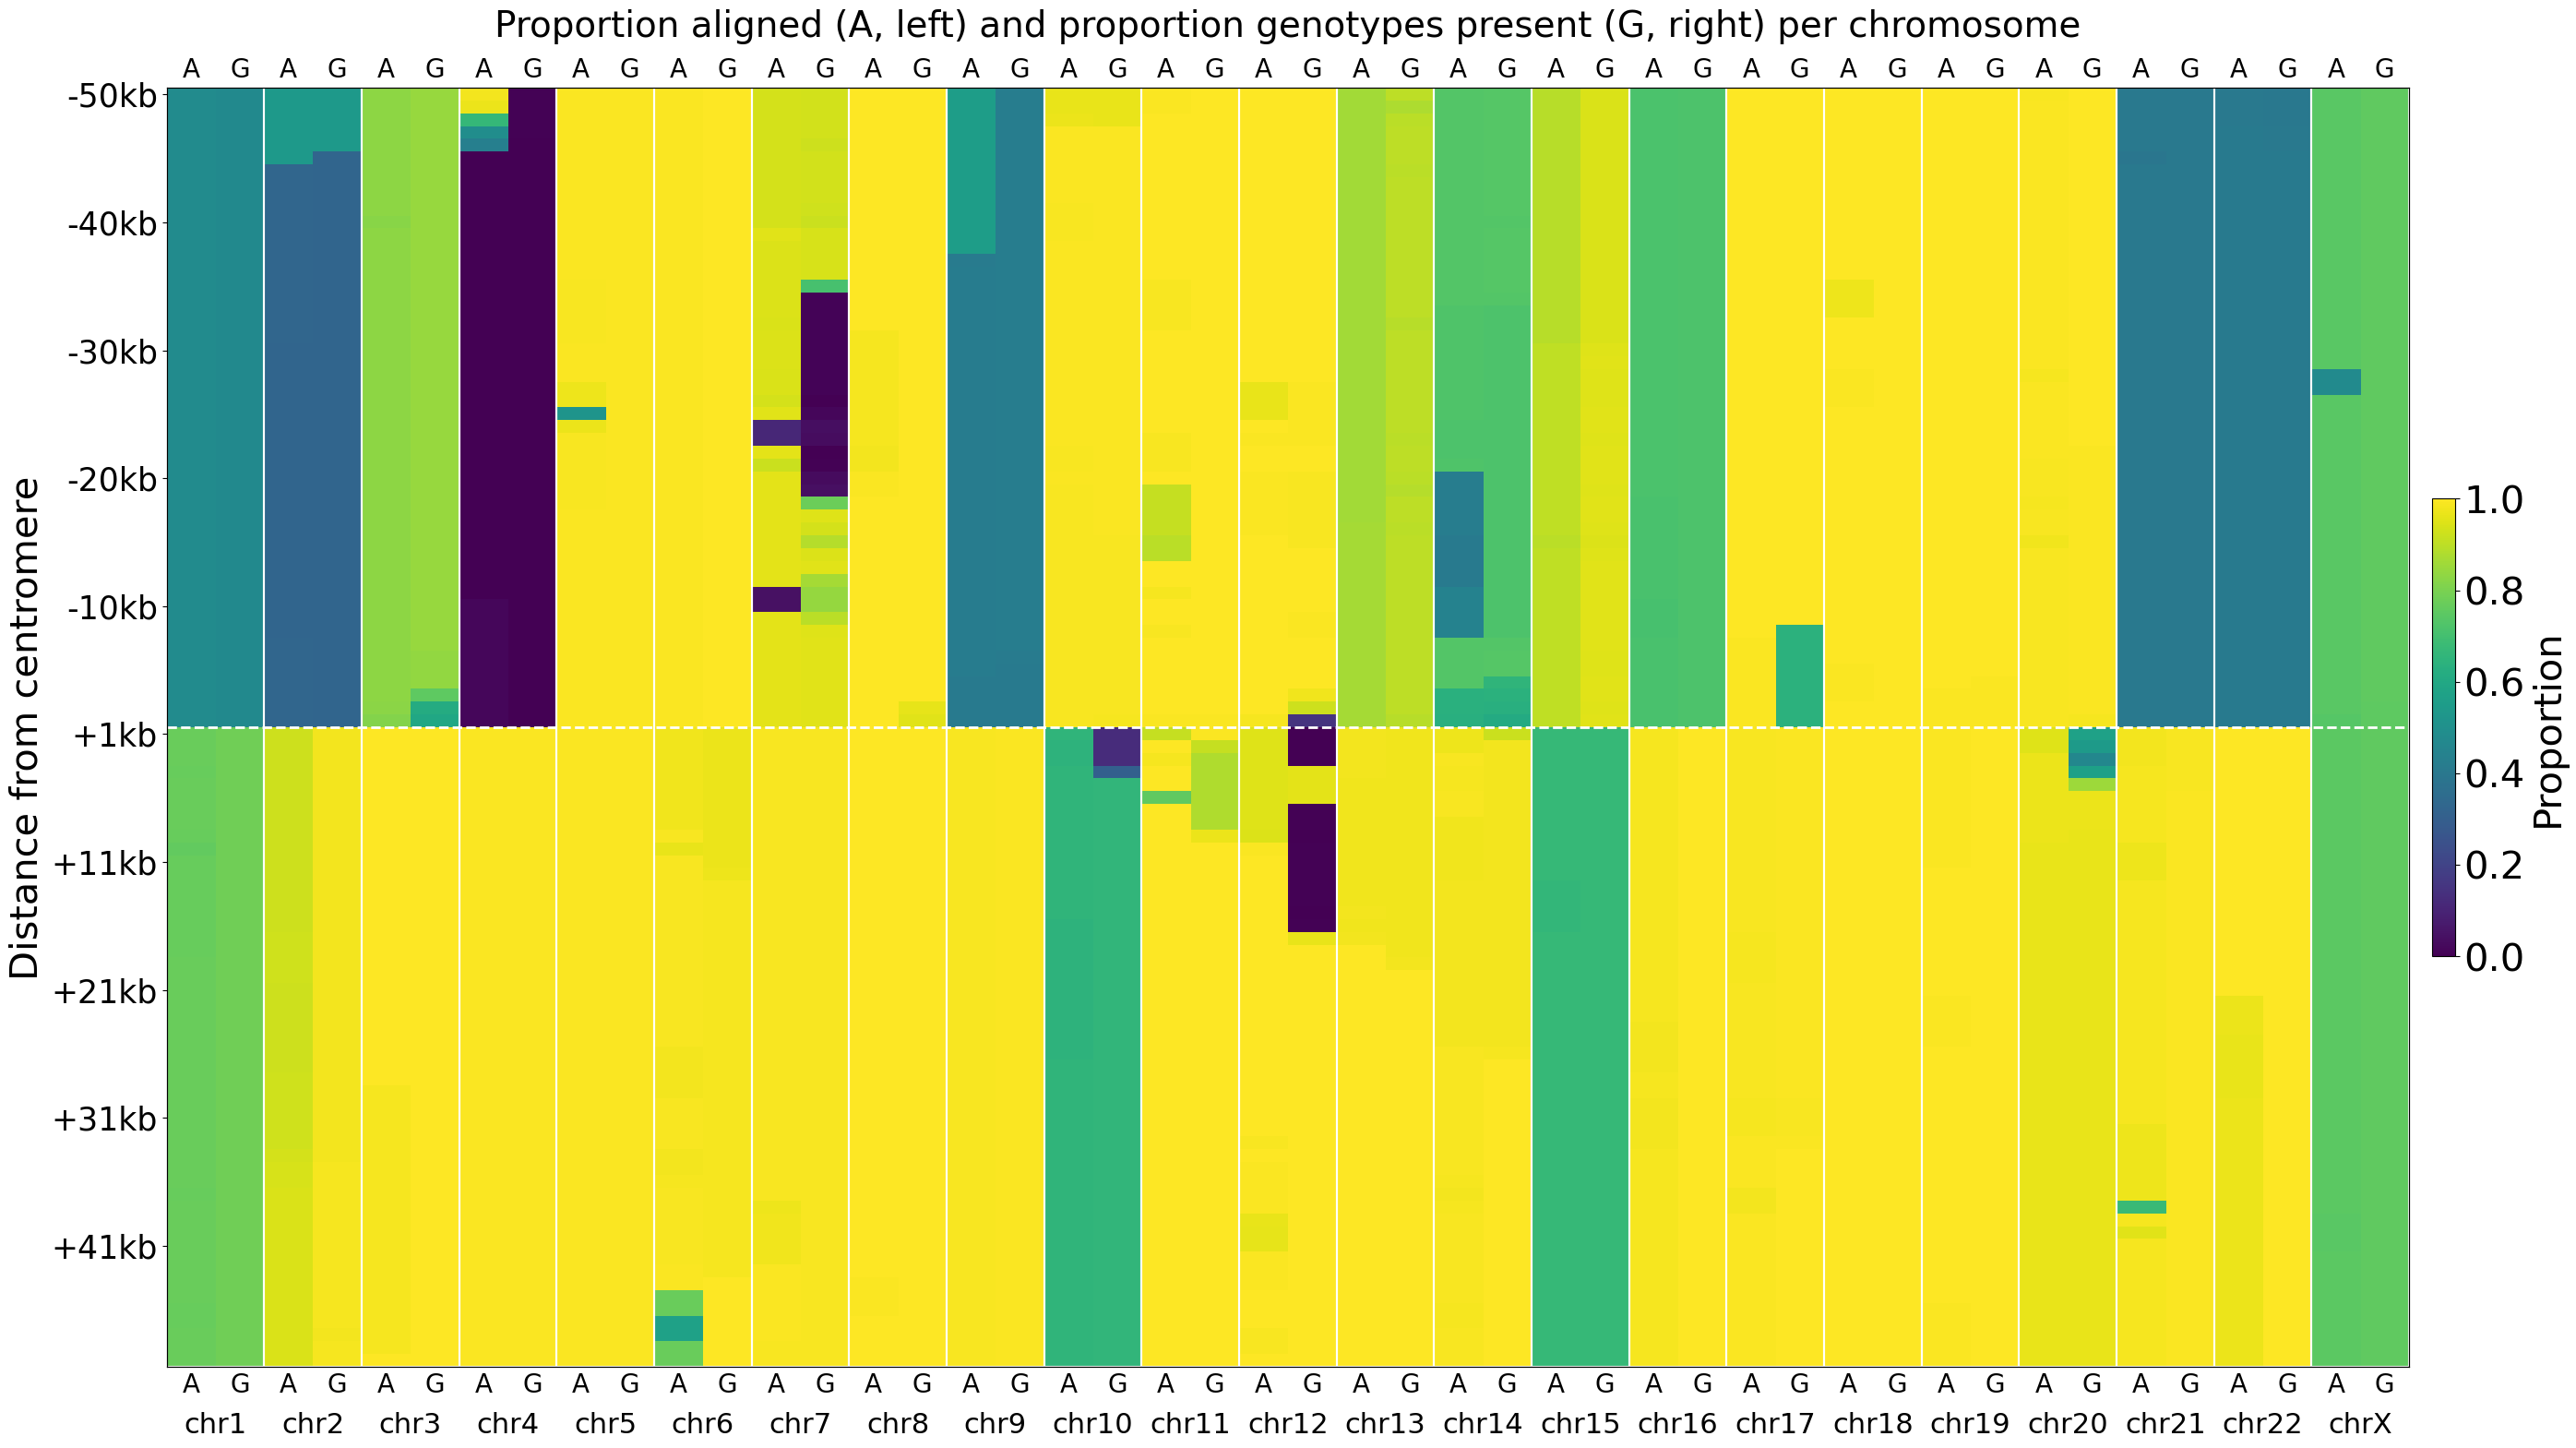

In [79]:
plot_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX"]
WINDOW_SIZE = 1000
FLANK_SIZE  = 50000
n_upstream   = FLANK_SIZE // WINDOW_SIZE
n_downstream = FLANK_SIZE // WINDOW_SIZE
n_rows       = n_upstream + n_downstream
n_chroms     = len(plot_chroms)

prop_aligned_mat = np.zeros((n_rows, n_chroms))
prop_present_mat = np.zeros((n_rows, n_chroms))

for ci, chrom in enumerate(plot_chroms):
    for flank in ("upstream", "downstream"):
        key = (chrom, flank)
        if key not in win_data:
            continue
        wd = win_data[key]
        for wi in range(wd["n_windows"]):
            row = wi if flank == "upstream" else n_upstream + wi
            if row >= n_rows:
                continue
            if wd["n_haps"] > 0:
                prop_aligned_mat[row, ci] = wd["aligned_count"][wi] / wd["n_haps"]
            if wd["n_genotypes"][wi] > 0:
                prop_present_mat[row, ci] = 1 - (wd["missing_count"][wi] / wd["n_genotypes"][wi])

combined = np.zeros((n_rows, n_chroms * 2))

for ci in range(n_chroms):
    combined[:, ci * 2]     = prop_aligned_mat[:, ci]
    combined[:, ci * 2 + 1] = prop_present_mat[:, ci]

def row_to_dist_kb(row):
    return -(n_upstream - row) if row < n_upstream else (row - n_upstream + 1)

tick_step = 10
y_ticks  = list(range(0, n_rows, tick_step))
y_labels = [f"{row_to_dist_kb(i):+d}kb" for i in y_ticks]

fig, ax = plt.subplots(figsize=(32, 18))
fig.subplots_adjust(bottom=0.15, top=0.92)

im = ax.imshow(combined, aspect="auto", cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
ax.axhline(n_upstream - 0.5, color="white", linewidth=2, linestyle="--")

for ci in range(n_chroms):
    ax.add_patch(plt.Rectangle(
        (ci * 2 - 0.5, -0.5), 2, n_rows,
        linewidth=1.5, edgecolor="white", facecolor="none"
    ))

# ── Bottom: aln / geno minor ticks + chrom major ticks ───────────────────────
minor_ticks  = [x for ci in range(n_chroms) for x in (ci * 2, ci * 2 + 1)]
minor_labels = ["A", "G"] * n_chroms
ax.set_xticks(minor_ticks, minor=True)
ax.set_xticklabels(minor_labels, minor=True, fontsize=20)
ax.tick_params(axis="x", which="minor", length=0, pad=4)

ax.set_xticks([ci * 2 + 0.5 for ci in range(n_chroms)])
ax.set_xticklabels(plot_chroms, fontsize=22, rotation=0, ha='center')
ax.tick_params(axis="x", which="major", length=0, pad=35)

# ── Top: aln / geno minor ticks only ─────────────────────────────────────────
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(minor_ticks, minor=True)
ax_top.set_xticklabels(["A", "G"] * n_chroms, minor=True, fontsize=20)
ax_top.tick_params(axis="x", which="minor", length=0, pad=4)
ax_top.set_xticks([ci * 2 + 0.5 for ci in range(n_chroms)])
ax_top.tick_params(axis="x", which="major", length=0, labeltop=False)

from matplotlib.ticker import FixedLocator, FixedFormatter

# Bottom
ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))
ax.xaxis.set_minor_formatter(FixedFormatter(["A", "G"] * n_chroms))
ax.tick_params(axis="x", which="minor", length=0, pad=4, labelsize=20)

# Top
ax_top.xaxis.set_minor_locator(FixedLocator(minor_ticks))
ax_top.xaxis.set_minor_formatter(FixedFormatter(["A", "G"] * n_chroms))
ax_top.tick_params(axis="x", which="minor", length=0, pad=4, labelsize=20)

# ── Y axis and colorbar ───────────────────────────────────────────────────────
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=25)
ax.set_ylabel("Distance from centromere", fontsize=30)

cbar = plt.colorbar(im, ax=ax, fraction=0.01, pad=0.01)
cbar.set_label("Proportion", fontsize=30)
cbar.ax.tick_params(labelsize=30)


plt.title("Proportion aligned (A, left) and proportion genotypes present (G, right) per chromosome",
          fontsize=28, pad=40)

plt.show()



In [80]:
mask = (prop_present_mat == 1.0) & (prop_aligned_mat < 1.0) & (prop_aligned_mat > 0.0)
rows_idx, cols_idx = np.where(mask)

for r, c in zip(rows_idx, cols_idx):
    print(f"chrom={plot_chroms[c]}, dist={row_to_dist_kb(r):+d}kb, "
          f"prop_aligned={prop_aligned_mat[r,c]:.3f}, prop_present={prop_present_mat[r,c]:.3f}")


chrom=chr6, dist=-50kb, prop_aligned=0.996, prop_present=1.000
chrom=chr8, dist=-50kb, prop_aligned=0.998, prop_present=1.000
chrom=chr11, dist=-50kb, prop_aligned=0.994, prop_present=1.000
chrom=chr18, dist=-50kb, prop_aligned=0.998, prop_present=1.000
chrom=chr6, dist=-49kb, prop_aligned=0.996, prop_present=1.000
chrom=chr8, dist=-49kb, prop_aligned=0.998, prop_present=1.000
chrom=chr11, dist=-49kb, prop_aligned=0.994, prop_present=1.000
chrom=chr18, dist=-49kb, prop_aligned=0.998, prop_present=1.000
chrom=chr6, dist=-48kb, prop_aligned=0.996, prop_present=1.000
chrom=chr8, dist=-48kb, prop_aligned=0.998, prop_present=1.000
chrom=chr18, dist=-48kb, prop_aligned=0.998, prop_present=1.000
chrom=chr6, dist=-47kb, prop_aligned=0.996, prop_present=1.000
chrom=chr8, dist=-47kb, prop_aligned=0.998, prop_present=1.000
chrom=chr18, dist=-47kb, prop_aligned=0.998, prop_present=1.000
chrom=chr6, dist=-46kb, prop_aligned=0.994, prop_present=1.000
chrom=chr8, dist=-46kb, prop_aligned=0.998, prop_

#### Compare flanks with array mutation rates

In [17]:
## Read in centrolign array mutation rates 

import pandas as pd
from pathlib import Path

chromosomes = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

output_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/per_cigar_mutation_rates")

dfs = []
for chrom in chromosomes:
    fp = output_dir / f"output_{chrom}.tsv"
    if fp.exists():
        dfs.append(pd.read_csv(fp, sep="\t"))

centrolign_df = pd.concat(dfs, ignore_index=True)
centrolign_df

,sample1,sample2,chr,avg_array_len,aligned_bases,n_snvs,n_snvs_per_aligned_base,n_snvs_per_aligned_base_per_avg_len,n_short_indels,n_short_indels_per_aligned_base,n_short_indels_per_aligned_base_per_avg_len,n_svs,n_svs_per_avg_len
0,HG02040.1,NA18983.1,chr1,4054652.5,3245747,1649,0.000508,1.253004e-10,110,0.000034,8.358424e-12,290,0.000072
1,HG00099.2,HG04204.1,chr1,3743784.0,3062338,1944,0.000635,1.695635e-10,141,0.000046,1.229859e-11,294,0.000079
2,HG002.2,HG01252.1,chr1,3893989.5,3463767,1864,0.000538,1.381982e-10,177,0.000051,1.312290e-11,244,0.000063
3,HG01099.1,NA20805.1,chr1,6613613.0,6199955,1266,0.000204,3.087496e-11,50,0.000008,1.219390e-12,236,0.000036
4,HG03041.1,HG03516.1,chr1,3535938.5,2891810,828,0.000286,8.097592e-11,44,0.000015,4.303068e-12,140,0.000040
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,HG002.1,HG01261.1,chrY,308747.0,246302,327,0.001328,4.300085e-09,46,0.000187,6.049050e-10,15,0.000049
4757,HG00621.1,NA18945.1,chrY,304226.0,263387,31,0.000118,3.868753e-10,2,0.000008,2.495970e-11,4,0.000013
4758,CHM13.0,HG002.1,chrY,317335.5,317335,0,0.000000,0.000000e+00,1,0.000003,9.930323e-12,0,0.000000
4759,NA18952.1,NA19043.1,chrY,141483.5,106828,87,0.000814,5.756100e-09,6,0.000056,3.969724e-10,7,0.000049


In [7]:
import numpy as np
import pandas as pd
import subprocess

VCF_DIR = "/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/flanking_50kb"
CHROMS  = [f"chr{i}" for i in list(range(1, 23)) + ["X"]]


def get_samples(vcf_path):
    result = subprocess.run(["bcftools", "query", "-l", vcf_path],
                            capture_output=True, text=True)
    return result.stdout.strip().split("\n")

def compute_pairwise_dist_split(vcf_path, chrom, flank_intervals):
    samples = get_samples(vcf_path)
    n_haps = len(samples) * 2
    hap_names = [f"{s}.{h}" for s in samples for h in (1, 2)]

    # Include CHROM and POS so we can classify each site as upstream/downstream
    cmd = (f"bcftools norm -m -any {vcf_path} "
           f"| bcftools view -v snps "
           f"| bcftools query -f '%CHROM\\t%POS\\t[%GT\\t]\\n'")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if not result.stdout.strip():
        return None

    upstream_rows   = []
    downstream_rows = []

    for line in result.stdout.strip().split("\n"):
        fields = line.strip().split("\t")
        site_chrom = fields[0]
        pos_0 = int(fields[1]) - 1  # VCF 1-based → 0-based
        gts   = fields[2:]

        flank = get_flank(pos_0, site_chrom, flank_intervals)
        if flank is None:
            continue

        row = np.empty(n_haps, dtype=np.int8)
        for i, gt in enumerate(gts):
            alleles = gt.replace("|", "/").split("/")
            try:    row[2*i]   = int(alleles[0])
            except: row[2*i]   = -1
            try:    row[2*i+1] = int(alleles[1])
            except: row[2*i+1] = -1

        if flank == "upstream":
            upstream_rows.append(row)
        else:
            downstream_rows.append(row)

    def diff_from_rows(rows):
        if not rows:
            return np.zeros((n_haps, n_haps), dtype=np.int32)
        A  = np.vstack(rows)
        V  = (A >= 0).astype(np.int32)
        A0 = (A == 0).astype(np.int32)
        A1 = (A == 1).astype(np.int32)
        return V.T @ V - (A0.T @ A0 + A1.T @ A1)

    up_diff   = diff_from_rows(upstream_rows)
    down_diff = diff_from_rows(downstream_rows)

    records = []
    for i in range(n_haps):
        for j in range(i+1, n_haps):
            records.append((hap_names[i], hap_names[j], chrom,
                            int(up_diff[i, j]), int(down_diff[i, j])))

    return pd.DataFrame(records, columns=["sample1", "sample2", "chr",
                                          "n_diff_sites_upstream", "n_diff_sites_downstream"])

flank_intervals = load_flank_intervals(FLANKS_BED)


all_dfs = []
for chrom in CHROMS:
    vcf_path = f"{VCF_DIR}/{chrom}_flanking_50kb.vcf.gz"
    print(f"Processing {chrom}...")
    df = compute_pairwise_dist_split(vcf_path, chrom, flank_intervals)
    if df is not None:
        all_dfs.append(df)

flank_dist_df = pd.concat(all_dfs, ignore_index=True)
flank_dist_df.head()


Processing chr1...
Processing chr2...
Processing chr3...
Processing chr4...
Processing chr5...
Processing chr6...
Processing chr7...
Processing chr8...
Processing chr9...
Processing chr10...
Processing chr11...
Processing chr12...
Processing chr13...
Processing chr14...
Processing chr15...
Processing chr16...
Processing chr17...
Processing chr18...
Processing chr19...
Processing chr20...
Processing chr21...
Processing chr22...
Processing chrX...


,sample1,sample2,chr,n_diff_sites_upstream,n_diff_sites_downstream
0,HG00097.1,HG00097.2,chr1,0,52
1,HG00097.1,HG00099.1,chr1,0,0
2,HG00097.1,HG00099.2,chr1,0,56
3,HG00097.1,HG00126.1,chr1,0,5
4,HG00097.1,HG00126.2,chr1,0,56


In [ ]:
## Unit tests
import unittest
import numpy as np
import subprocess
import tempfile
import os

# ── Core distance logic (extracted for testing) ───────────────────────────────

def dist_from_allele_matrix(A):
    """A: (n_sites, n_haps) int8, -1=missing. Returns (n_haps, n_haps) diff count."""
    V  = (A >= 0).astype(np.int32)
    A0 = (A == 0).astype(np.int32)
    A1 = (A == 1).astype(np.int32)
    return V.T @ V - (A0.T @ A0 + A1.T @ A1)

def parse_gt_line(line, n_haps):
    """Parse one bcftools query GT line into a row of alleles."""
    gts = line.strip().split("\t")
    row = np.empty(n_haps, dtype=np.int8)
    for i, gt in enumerate(gts):
        alleles = gt.replace("|", "/").split("/")
        try:    row[2*i]   = int(alleles[0])
        except: row[2*i]   = -1
        try:    row[2*i+1] = int(alleles[1])
        except: row[2*i+1] = -1
    return row


# ── Unit tests ────────────────────────────────────────────────────────────────

class TestDistMatrix(unittest.TestCase):

    def test_identical_haplotypes(self):
        """Two haplotypes with same allele at every site → 0 differences."""
        A = np.array([[0, 0],
                      [1, 1],
                      [0, 0]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 0)

    def test_all_different(self):
        """Two haplotypes differ at every site."""
        A = np.array([[0, 1],
                      [0, 1],
                      [1, 0]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 3)

    def test_one_differing_site(self):
        A = np.array([[0, 0],
                      [0, 1],   # differs here
                      [1, 1]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 1)

    def test_missing_excluded_from_diff(self):
        """Site where one haplotype is missing should NOT count as a difference."""
        A = np.array([[ 0, -1],   # hap1 missing → skip
                      [ 0,  1]], dtype=np.int8)  # differs → count
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 1)

    def test_both_missing_not_counted(self):
        """Site where both haplotypes are missing → 0."""
        A = np.array([[-1, -1],
                      [ 0,  1]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 1)

    def test_all_missing_one_hap(self):
        """One haplotype entirely missing → all pairs with it = 0 diffs."""
        A = np.array([[-1, 0, 1],
                      [-1, 1, 0]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 0)
        self.assertEqual(D[0, 2], 0)
        self.assertEqual(D[1, 2], 2)  # hap1 vs hap2 still counted

    def test_symmetry(self):
        A = np.array([[0, 1, 0],
                      [1, 0, 1]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        np.testing.assert_array_equal(D, D.T)

    def test_diagonal_zero(self):
        """Self-distance should always be 0."""
        A = np.array([[0, 1, -1],
                      [1, 0,  0]], dtype=np.int8)
        D = dist_from_allele_matrix(A)
        np.testing.assert_array_equal(np.diag(D), [0, 0, 0])

    def test_three_haplotypes(self):
        #          hap0 hap1 hap2
        A = np.array([[0,   1,   0],   # hap0==hap2, hap1 differs
                      [1,   1,   0],   # hap0==hap1, hap2 differs
                      [0,   0,   0]], dtype=np.int8)  # all same
        D = dist_from_allele_matrix(A)
        self.assertEqual(D[0, 1], 1)   # differ at site 0
        self.assertEqual(D[0, 2], 1)   # differ at site 1
        self.assertEqual(D[1, 2], 2)   # differ at sites 0 and 1


class TestParseGtLine(unittest.TestCase):

    def test_phased_gt(self):
        row = parse_gt_line("0|0\t0|1\t1|0", n_haps=6)
        np.testing.assert_array_equal(row, [0, 0, 0, 1, 1, 0])

    def test_unphased_gt(self):
        row = parse_gt_line("0/1\t0/0", n_haps=4)
        np.testing.assert_array_equal(row, [0, 1, 0, 0])

    def test_missing_dot(self):
        row = parse_gt_line(".|.\t0|1", n_haps=4)
        np.testing.assert_array_equal(row, [-1, -1, 0, 1])

    def test_half_missing(self):
        row = parse_gt_line("0|.\t1|0", n_haps=4)
        np.testing.assert_array_equal(row, [0, -1, 1, 0])


unittest.main(argv=[""], exit=False, verbosity=2)


test_all_different (__main__.TestDistMatrix.test_all_different)
Two haplotypes differ at every site. ... ok
test_all_missing_one_hap (__main__.TestDistMatrix.test_all_missing_one_hap)
One haplotype entirely missing → all pairs with it = 0 diffs. ... ok
test_both_missing_not_counted (__main__.TestDistMatrix.test_both_missing_not_counted)
Site where both haplotypes are missing → 0. ... ok
test_diagonal_zero (__main__.TestDistMatrix.test_diagonal_zero)
Self-distance should always be 0. ... ok
test_identical_haplotypes (__main__.TestDistMatrix.test_identical_haplotypes)
Two haplotypes with same allele at every site → 0 differences. ... ok
test_missing_excluded_from_diff (__main__.TestDistMatrix.test_missing_excluded_from_diff)
Site where one haplotype is missing should NOT count as a difference. ... ok
test_one_differing_site (__main__.TestDistMatrix.test_one_differing_site) ... ok
test_symmetry (__main__.TestDistMatrix.test_symmetry) ... ok
test_three_haplotypes (__main__.TestDistMatrix.t

In [9]:
import pandas as pd
from pathlib import Path

shared_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/mutation_rate_comparison_to_flanks/pairwise_shared_aligned_bases")

shared_bases_df = pd.concat(
    [pd.read_csv(f, sep="\t") for f in sorted(shared_dir.glob("*_pairwise_shared_aligned_bases.tsv"))],
    ignore_index=True
)

# Extract chrom from filename isn't needed since it's not in the file —
# derive it by adding a chr column from the filename
dfs = []
for f in sorted(shared_dir.glob("*_pairwise_shared_aligned_bases.tsv")):
    chrom = f.name.replace("_pairwise_shared_aligned_bases.tsv", "")
    df = pd.read_csv(f, sep="\t")
    df["chr"] = chrom
    dfs.append(df)

shared_bases_df = pd.concat(dfs, ignore_index=True)
shared_bases_df["sample_pair"] = shared_bases_df[["hap1", "hap2"]].apply(
    lambda x: "_".join(sorted(x)), axis=1
)
print(shared_bases_df.shape)
shared_bases_df.head()


(5111568, 6)


,hap1,hap2,flank,shared_bases,chr,sample_pair
0,HG00097.1,HG00097.2,upstream,49046,chr10,HG00097.1_HG00097.2
1,HG00097.1,HG00097.2,downstream,0,chr10,HG00097.1_HG00097.2
2,HG00097.1,HG00099.1,upstream,49046,chr10,HG00097.1_HG00099.1
3,HG00097.1,HG00099.1,downstream,0,chr10,HG00097.1_HG00099.1
4,HG00097.1,HG00099.2,upstream,50000,chr10,HG00097.1_HG00099.2


In [14]:
flank_dist_df["sample_pair"] = flank_dist_df[["sample1", "sample2"]].apply(
    lambda x: "_".join(sorted(x)), axis=1
)

# Merge shared bases (already long with flank column)
merged_df = flank_dist_df.melt(
    id_vars=["sample1", "sample2", "sample_pair", "chr"],
    value_vars=["n_diff_sites_upstream", "n_diff_sites_downstream"],
    var_name="flank",
    value_name="n_diff_sites"
)
merged_df["flank"] = merged_df["flank"].str.replace("n_diff_sites_", "")

merged_df = merged_df.merge(
    shared_bases_df[["sample_pair", "chr", "flank", "shared_bases"]],
    on=["sample_pair", "chr", "flank"],
    how="left"
)

merged_df["SNV_rate"]     = merged_df["n_diff_sites"] / merged_df["shared_bases"]
merged_df["prop_aligned"] = merged_df["shared_bases"] / 50000

merged_df.tail()



,sample1,sample2,sample_pair,chr,flank,n_diff_sites,shared_bases,SNV_rate,prop_aligned
3156469,NA21110.1,NA21144.1,NA21110.1_NA21144.1,chrX,downstream,15,50000,0.00030,1.0
3156470,NA21110.1,NA21144.2,NA21110.1_NA21144.2,chrX,downstream,20,50000,0.00040,1.0
3156471,NA21110.2,NA21144.1,NA21110.2_NA21144.1,chrX,downstream,16,50000,0.00032,1.0
3156472,NA21110.2,NA21144.2,NA21110.2_NA21144.2,chrX,downstream,21,50000,0.00042,1.0
3156473,NA21144.1,NA21144.2,NA21144.1_NA21144.2,chrX,downstream,5,50000,0.00010,1.0


In [15]:
# remove either up or downstream rows with less than 50% aligned bases 

merged_df_filt = merged_df[merged_df["prop_aligned"] >= 0.5]
avg_snv_df = (
    merged_df_filt.groupby(["sample_pair", "chr"])["SNV_rate"]
    .mean()
    .reset_index()
    .rename(columns={"SNV_rate": "avg_SNV_rate"})
)
avg_snv_df.head()


,sample_pair,chr,avg_SNV_rate
0,HG00097.1_HG00097.2,chr1,0.001040
1,HG00097.1_HG00097.2,chr10,0.008910
2,HG00097.1_HG00097.2,chr11,0.000290
3,HG00097.1_HG00097.2,chr12,0.000242
4,HG00097.1_HG00097.2,chr13,0.001821


Common sample_pair+chr combinations: 4453


/data/tmp/ipykernel_2833491/2162363053.py:47: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


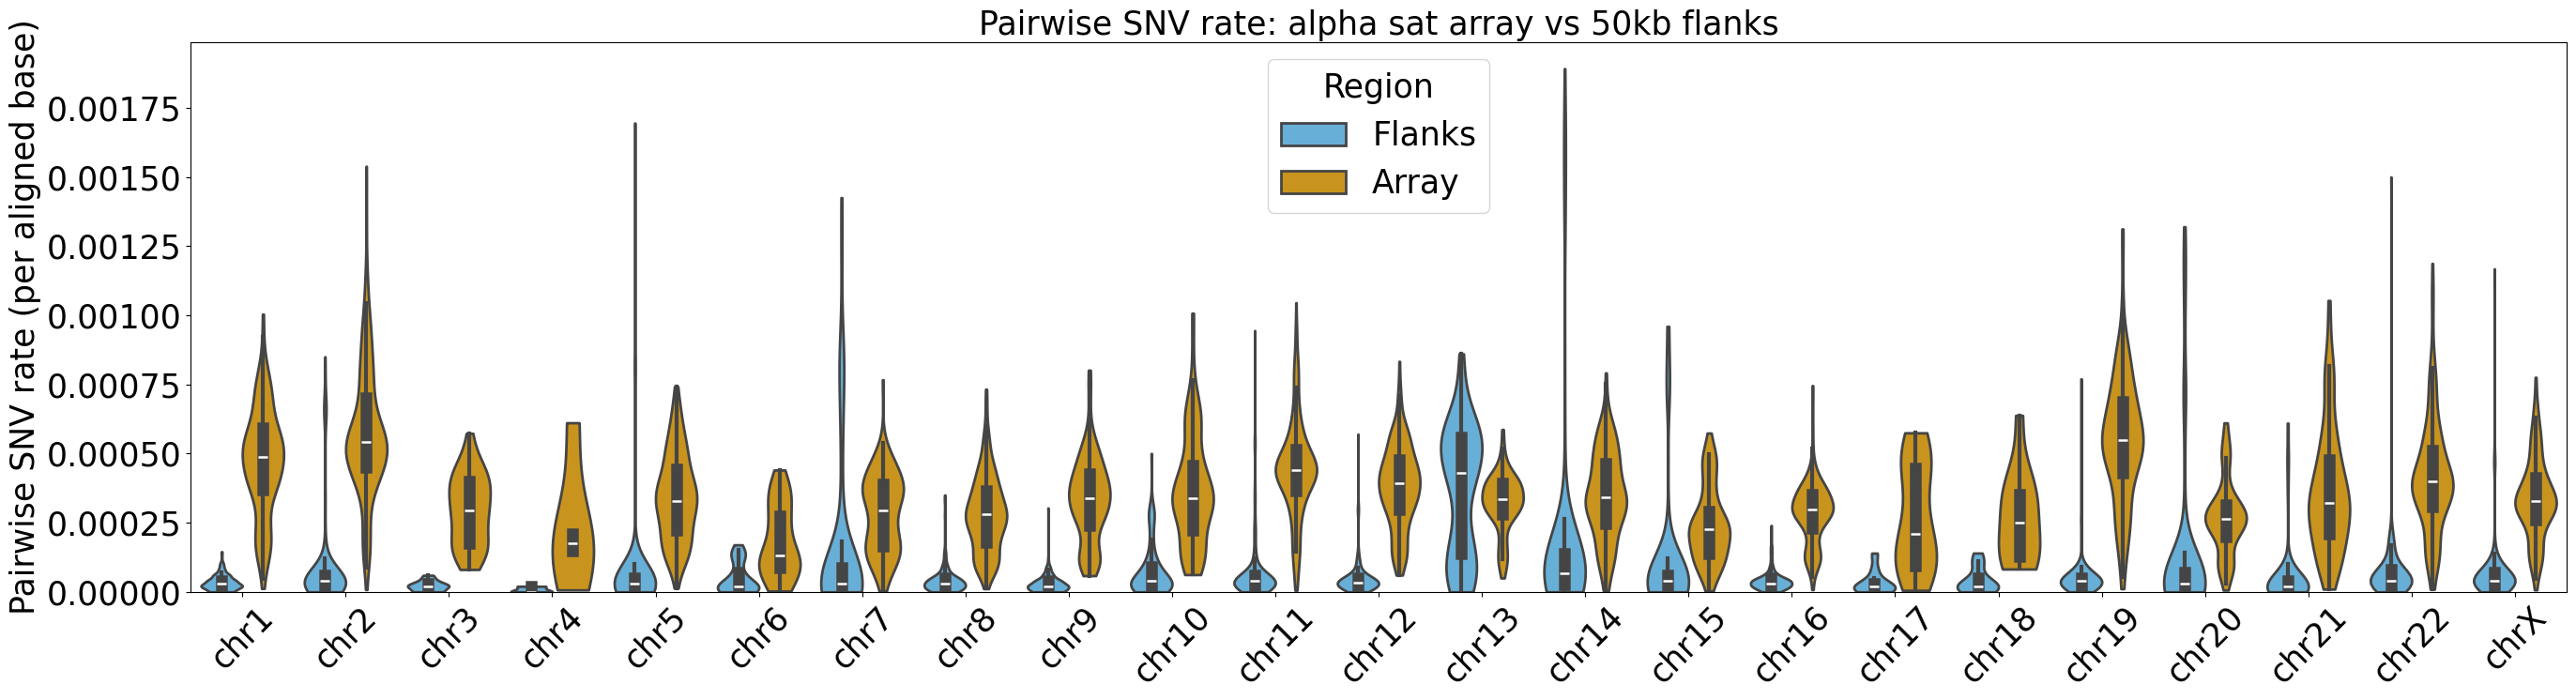

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "legend.title_fontsize": 25,
})


centrolign_df["sample_pair"] = centrolign_df[["sample1", "sample2"]].apply(
    lambda x: "_".join(sorted(x)), axis=1
)


# Find common sample_pair + chr combinations
common_keys = set(zip(avg_snv_df["sample_pair"], avg_snv_df["chr"])) & \
              set(zip(centrolign_df["sample_pair"], centrolign_df["chr"]))

# Prepare both dataframes with common structure, filtered to common pairs
df_flank = avg_snv_df[avg_snv_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "avg_SNV_rate"]].copy()
df_flank["source"] = "Flanks"
df_flank = df_flank.rename(columns={"avg_SNV_rate": "SNV_rate"})

df_array = centrolign_df[centrolign_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "n_snvs_per_aligned_base"]].copy()
df_array["source"] = "Array"
df_array = df_array.rename(columns={"n_snvs_per_aligned_base": "SNV_rate"})

print(f"Common sample_pair+chr combinations: {len(common_keys)}")

plot_df = pd.concat([df_flank, df_array], ignore_index=True)

chroms = [f"chr{i}" for i in list(range(1, 23)) + ["X"]]
plot_df = plot_df[plot_df["chr"].isin(chroms)]
plot_df["chr"] = pd.Categorical(plot_df["chr"], categories=chroms, ordered=True)

Q1 = plot_df["SNV_rate"].quantile(0.01)
Q3 = plot_df["SNV_rate"].quantile(0.99)
plot_df = plot_df[(plot_df["SNV_rate"] >= Q1) & (plot_df["SNV_rate"] <= Q3)]

fig, ax = plt.subplots(figsize=(28, 8))

sns.violinplot(
    data=plot_df,
    x="chr", y="SNV_rate",
    hue="source",
    split=False,
    inner="box",
    linewidth=2,
    palette={"Array": "#E69F00", "Flanks": "#56B4E9"},
    scale="width",
    cut=0,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Pairwise SNV rate (per aligned base)")
ax.set_title("Pairwise SNV rate: alpha sat array vs 50kb flanks")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.legend(title="Region")

ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()



Common sample_pair+chr combinations: 4453


/data/tmp/ipykernel_2833491/2721850812.py:47: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


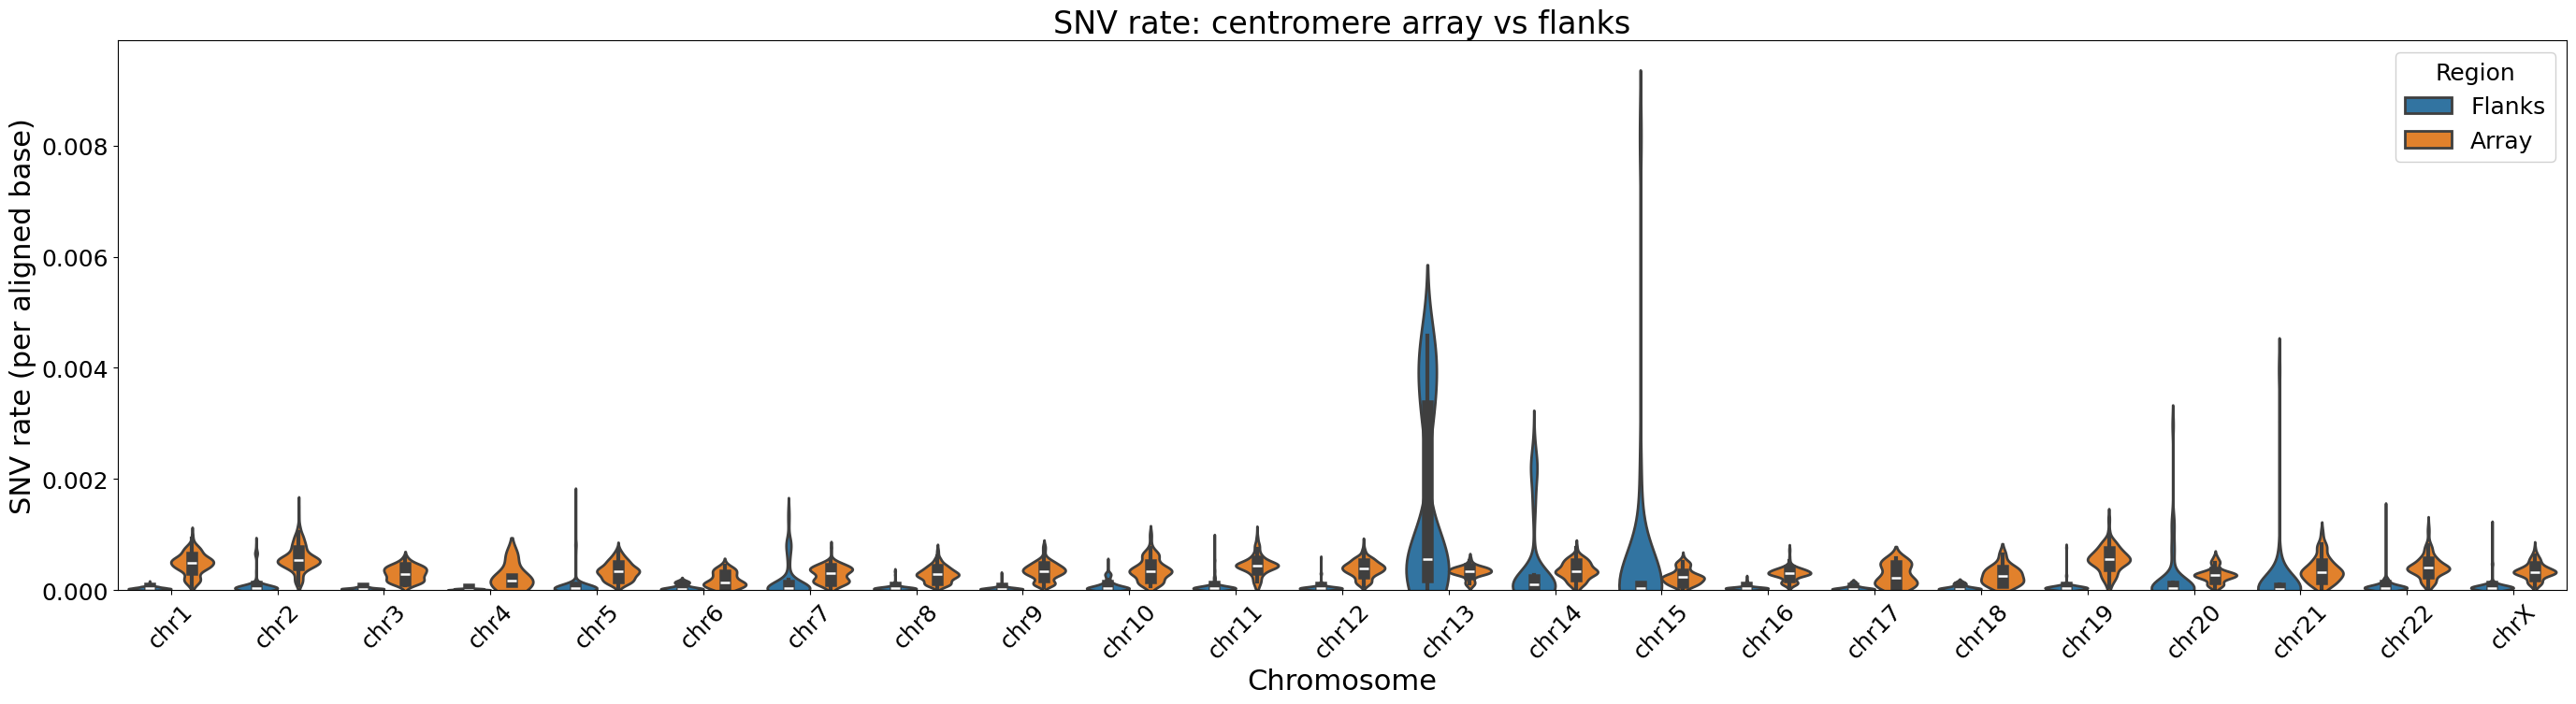

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 22,
})


centrolign_df["sample_pair"] = centrolign_df[["sample1", "sample2"]].apply(
    lambda x: "_".join(sorted(x)), axis=1
)


# Find common sample_pair + chr combinations
common_keys = set(zip(avg_snv_df["sample_pair"], avg_snv_df["chr"])) & \
              set(zip(centrolign_df["sample_pair"], centrolign_df["chr"]))

# Prepare both dataframes with common structure, filtered to common pairs
df_flank = avg_snv_df[avg_snv_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "avg_SNV_rate"]].copy()
df_flank["source"] = "Flanks"
df_flank = df_flank.rename(columns={"avg_SNV_rate": "SNV_rate"})

df_array = centrolign_df[centrolign_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "n_snvs_per_aligned_base"]].copy()
df_array["source"] = "Array"
df_array = df_array.rename(columns={"n_snvs_per_aligned_base": "SNV_rate"})

print(f"Common sample_pair+chr combinations: {len(common_keys)}")

plot_df = pd.concat([df_flank, df_array], ignore_index=True)

chroms = [f"chr{i}" for i in list(range(1, 23)) + ["X"]]
plot_df = plot_df[plot_df["chr"].isin(chroms)]
plot_df["chr"] = pd.Categorical(plot_df["chr"], categories=chroms, ordered=True)

#Q1 = plot_df["SNV_rate"].quantile(0.01)
#Q3 = plot_df["SNV_rate"].quantile(0.99)
#plot_df = plot_df[(plot_df["SNV_rate"] >= Q1) & (plot_df["SNV_rate"] <= Q3)]

fig, ax = plt.subplots(figsize=(28, 8))

sns.violinplot(
    data=plot_df,
    x="chr", y="SNV_rate",
    hue="source",
    split=False,
    inner="box",
    linewidth=2,
    scale="width",
    ax=ax
)

ax.set_xlabel("Chromosome", fontsize=22)
ax.set_ylabel("SNV rate (per aligned base)", fontsize=22)
ax.set_title("SNV rate: centromere array vs flanks", fontsize=24)
ax.tick_params(axis="x", rotation=45, labelsize=18)
ax.tick_params(axis="y", labelsize=18)

legend = ax.legend(title="Region", fontsize=18, title_fontsize=18,
                   markerscale=2, framealpha=0.9)

ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### Short indels 

In [42]:
def compute_pairwise_indel_dist_split(vcf_path, chrom, flank_intervals):
    samples = get_samples(vcf_path)
    n_haps = len(samples) * 2
    hap_names = [f"{s}.{h}" for s in samples for h in (1, 2)]

    # Include REF and ALT to filter indel size
    cmd = (f"bcftools norm -m -any {vcf_path} "
           f"| bcftools view -v indels "
           f"| bcftools query -f '%CHROM\\t%POS\\t%REF\\t%ALT\\t[%GT\\t]\\n'")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

    if not result.stdout.strip():
        return None

    upstream_rows   = []
    downstream_rows = []

    for line in result.stdout.strip().split("\n"):
        fields     = line.strip().split("\t")
        site_chrom = fields[0]
        pos_0      = int(fields[1]) - 1
        ref        = fields[2]
        alt        = fields[3]
        gts        = fields[4:]

        # Filter to short indels < 50 bp
        if abs(len(ref) - len(alt)) >= 50:
            continue

        flank = get_flank(pos_0, site_chrom, flank_intervals)
        if flank is None:
            continue

        row = np.empty(n_haps, dtype=np.int8)
        for i, gt in enumerate(gts):
            alleles = gt.replace("|", "/").split("/")
            try:    row[2*i]   = int(alleles[0])
            except: row[2*i]   = -1
            try:    row[2*i+1] = int(alleles[1])
            except: row[2*i+1] = -1

        if flank == "upstream":
            upstream_rows.append(row)
        else:
            downstream_rows.append(row)

    def diff_from_rows(rows):
        if not rows:
            return np.zeros((n_haps, n_haps), dtype=np.int32)
        A  = np.vstack(rows)
        V  = (A >= 0).astype(np.int32)
        A0 = (A == 0).astype(np.int32)
        A1 = (A == 1).astype(np.int32)
        return V.T @ V - (A0.T @ A0 + A1.T @ A1)

    up_diff   = diff_from_rows(upstream_rows)
    down_diff = diff_from_rows(downstream_rows)

    records = []
    for i in range(n_haps):
        for j in range(i+1, n_haps):
            records.append((hap_names[i], hap_names[j], chrom,
                            int(up_diff[i, j]), int(down_diff[i, j])))

    return pd.DataFrame(records, columns=["sample1", "sample2", "chr",
                                          "n_diff_indel_sites_upstream",
                                          "n_diff_indel_sites_downstream"])

all_dfs = []
for chrom in CHROMS:
    vcf_path = f"{VCF_DIR}/{chrom}_flanking_50kb.vcf.gz"
    print(f"Processing {chrom}...")
    df = compute_pairwise_indel_dist_split(vcf_path, chrom, flank_intervals)
    if df is not None:
        all_dfs.append(df)

flank_indel_dist_df = pd.concat(all_dfs, ignore_index=True)
flank_indel_dist_df.head()


Processing chr1...
Processing chr2...
Processing chr3...
Processing chr4...
Processing chr5...
Processing chr6...
Processing chr7...
Processing chr8...
Processing chr9...
Processing chr10...
Processing chr11...
Processing chr12...
Processing chr13...
Processing chr14...
Processing chr15...
Processing chr16...
Processing chr17...
Processing chr18...
Processing chr19...
Processing chr20...
Processing chr21...
Processing chr22...
Processing chrX...


,sample1,sample2,chr,n_diff_indel_sites_upstream,n_diff_indel_sites_downstream
0,HG00097.1,HG00097.2,chr1,0,2
1,HG00097.1,HG00099.1,chr1,0,0
2,HG00097.1,HG00099.2,chr1,0,2
3,HG00097.1,HG00126.1,chr1,0,0
4,HG00097.1,HG00126.2,chr1,0,2


In [43]:
flank_indel_dist_df["sample_pair"] = flank_indel_dist_df[["sample1", "sample2"]].apply(
    lambda x: "_".join(sorted(x)), axis=1
)

merged_indel_df = flank_indel_dist_df.melt(
    id_vars=["sample1", "sample2", "sample_pair", "chr"],
    value_vars=["n_diff_indel_sites_upstream", "n_diff_indel_sites_downstream"],
    var_name="flank",
    value_name="n_diff_indel_sites"
)
merged_indel_df["flank"] = merged_indel_df["flank"].str.replace("n_diff_indel_sites_", "")

merged_indel_df = merged_indel_df.merge(
    shared_bases_df[["sample_pair", "chr", "flank", "shared_bases"]],
    on=["sample_pair", "chr", "flank"],
    how="left"
)

merged_indel_df["indel_rate"] = merged_indel_df["n_diff_indel_sites"] / merged_indel_df["shared_bases"]
merged_indel_df["prop_aligned"] = merged_indel_df["shared_bases"] / 50000

merged_indel_df.tail()


,sample1,sample2,sample_pair,chr,flank,n_diff_indel_sites,shared_bases,indel_rate,prop_aligned
3156469,NA21110.1,NA21144.1,NA21110.1_NA21144.1,chrX,downstream,0,50000,0.0,1.0
3156470,NA21110.1,NA21144.2,NA21110.1_NA21144.2,chrX,downstream,0,50000,0.0,1.0
3156471,NA21110.2,NA21144.1,NA21110.2_NA21144.1,chrX,downstream,0,50000,0.0,1.0
3156472,NA21110.2,NA21144.2,NA21110.2_NA21144.2,chrX,downstream,0,50000,0.0,1.0
3156473,NA21144.1,NA21144.2,NA21144.1_NA21144.2,chrX,downstream,0,50000,0.0,1.0


In [44]:
merged_indel_df_filt = merged_indel_df[merged_indel_df["prop_aligned"] >= 0.5]
avg_indel_df = (
    merged_indel_df_filt.groupby(["sample_pair", "chr"])["indel_rate"]
    .mean()
    .reset_index()
    .rename(columns={"indel_rate": "avg_indel_rate"})
)
avg_indel_df.head()


,sample_pair,chr,avg_indel_rate
0,HG00097.1_HG00097.2,chr1,0.000040
1,HG00097.1_HG00097.2,chr10,0.000408
2,HG00097.1_HG00097.2,chr11,0.000020
3,HG00097.1_HG00097.2,chr12,0.000020
4,HG00097.1_HG00097.2,chr13,0.000310


Common sample_pair+chr combinations: 4453


/data/tmp/ipykernel_2833491/1940848484.py:36: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


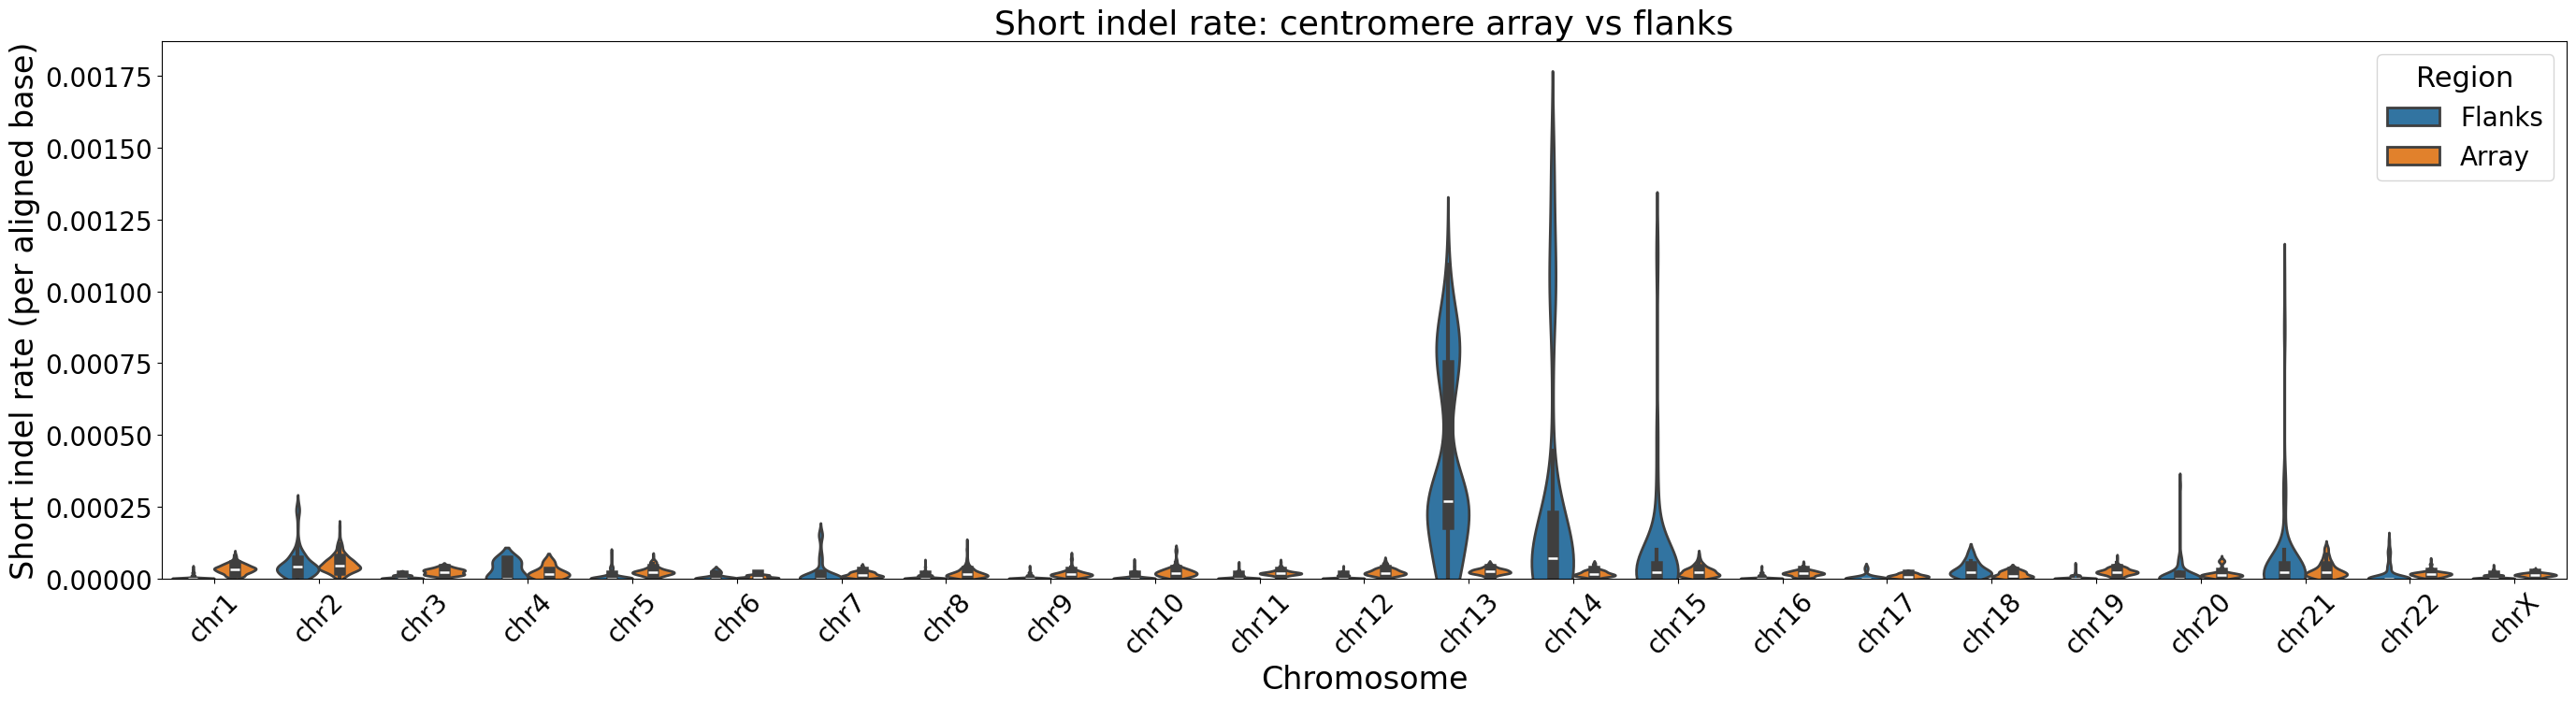

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 22,
})

# Find common sample_pair + chr combinations
common_keys = set(zip(avg_indel_df["sample_pair"], avg_indel_df["chr"])) & \
              set(zip(centrolign_df["sample_pair"], centrolign_df["chr"]))

df_flank = avg_indel_df[avg_indel_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "avg_indel_rate"]].copy()
df_flank["source"] = "Flanks"
df_flank = df_flank.rename(columns={"avg_indel_rate": "indel_rate"})

df_array = centrolign_df[centrolign_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "n_short_indels_per_aligned_base"]].copy()
df_array["source"] = "Array"
df_array = df_array.rename(columns={"n_short_indels_per_aligned_base": "indel_rate"})

print(f"Common sample_pair+chr combinations: {len(common_keys)}")

plot_df = pd.concat([df_flank, df_array], ignore_index=True)

chroms = [f"chr{i}" for i in list(range(1, 23)) + ["X"]]
plot_df = plot_df[plot_df["chr"].isin(chroms)]
plot_df["chr"] = pd.Categorical(plot_df["chr"], categories=chroms, ordered=True)

fig, ax = plt.subplots(figsize=(28, 8))

sns.violinplot(
    data=plot_df,
    x="chr", y="indel_rate",
    hue="source",
    split=False,
    inner="box",
    linewidth=2,
    scale="width",
    ax=ax
)

ax.set_xlabel("Chromosome")
ax.set_ylabel("Short indel rate (per aligned base)")
ax.set_title("Short indel rate: centromere array vs flanks")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.legend(title="Region")

plt.tight_layout()
plt.show()


Common sample_pair+chr combinations: 4453


/data/tmp/ipykernel_2833491/2229650721.py:44: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


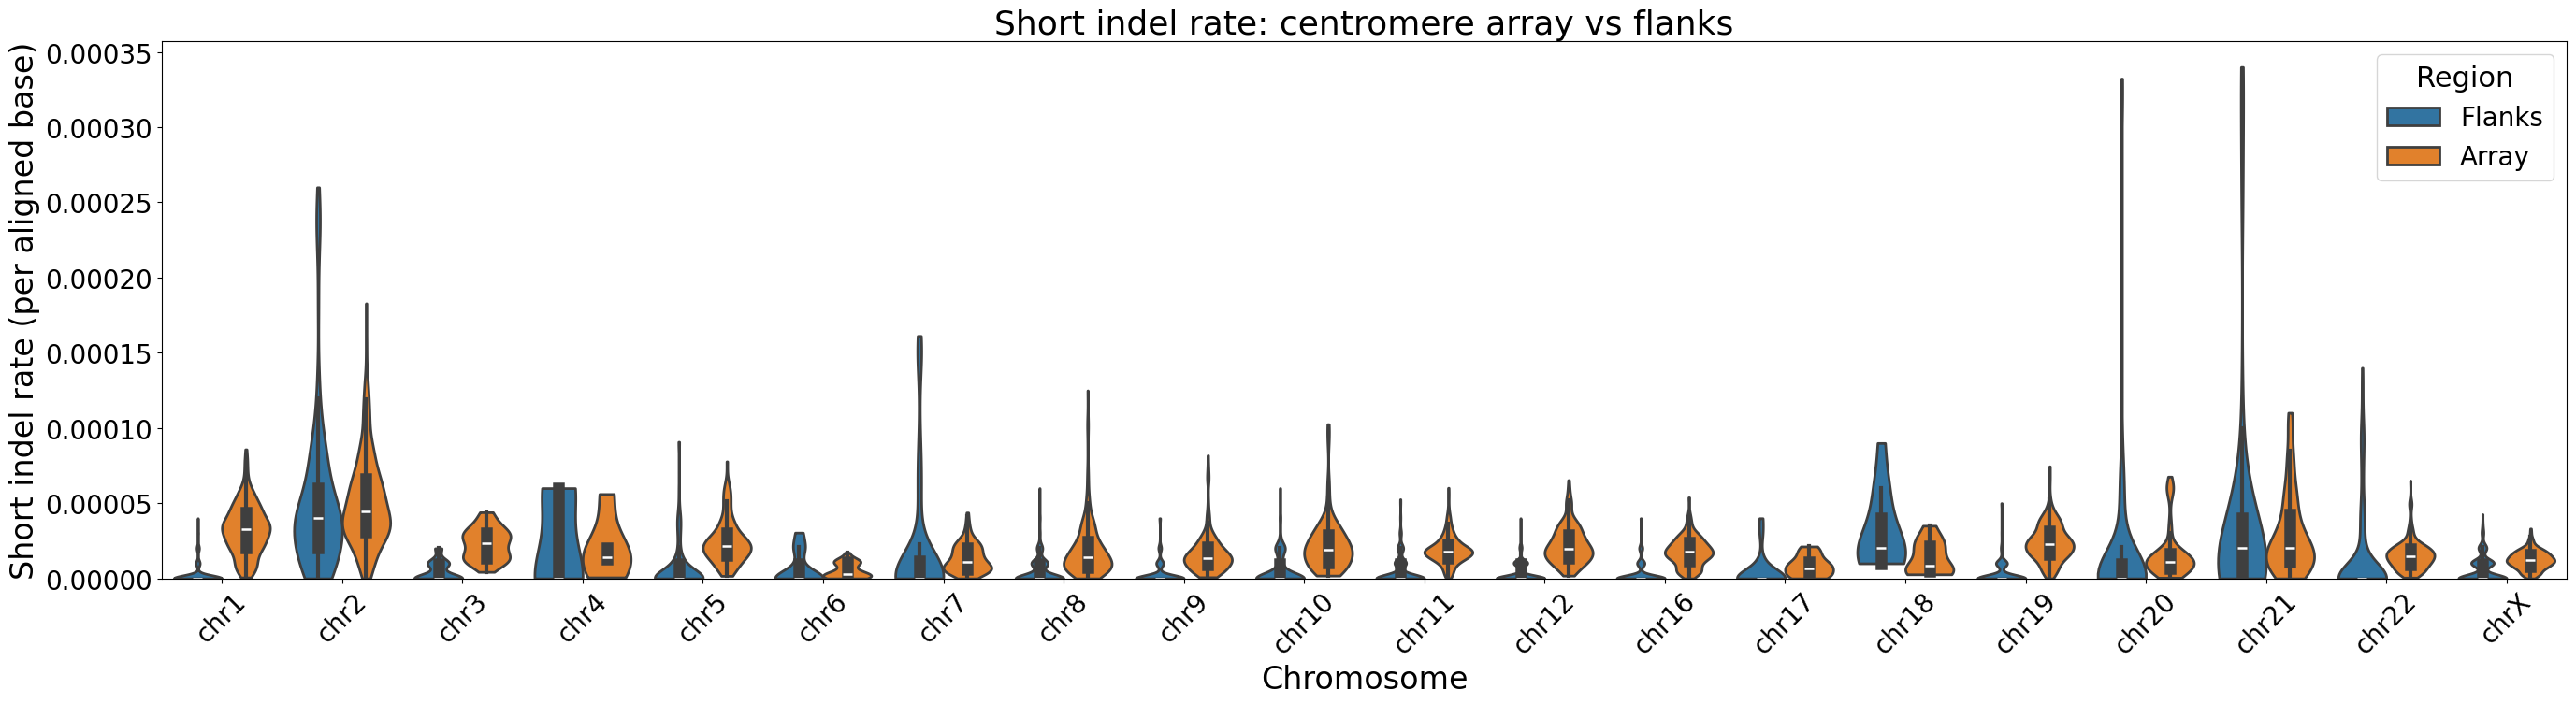

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 22,
})

# Find common sample_pair + chr combinations
common_keys = set(zip(avg_indel_df["sample_pair"], avg_indel_df["chr"])) & \
              set(zip(centrolign_df["sample_pair"], centrolign_df["chr"]))

df_flank = avg_indel_df[avg_indel_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "avg_indel_rate"]].copy()
df_flank["source"] = "Flanks"
df_flank = df_flank.rename(columns={"avg_indel_rate": "indel_rate"})

df_array = centrolign_df[centrolign_df.apply(lambda r: (r["sample_pair"], r["chr"]) in common_keys, axis=1)][["chr", "n_short_indels_per_aligned_base"]].copy()
df_array["source"] = "Array"
df_array = df_array.rename(columns={"n_short_indels_per_aligned_base": "indel_rate"})

print(f"Common sample_pair+chr combinations: {len(common_keys)}")

plot_df = pd.concat([df_flank, df_array], ignore_index=True)

chroms = [f"chr{i}" for i in list(range(1, 23)) + ["X"]]
plot_df = plot_df[plot_df["chr"].isin(chroms)]
plot_df["chr"] = pd.Categorical(plot_df["chr"], categories=chroms, ordered=True)

Q1 = plot_df["indel_rate"].quantile(0.01)
Q3 = plot_df["indel_rate"].quantile(0.99)
plot_df = plot_df[(plot_df["indel_rate"] >= Q1) & (plot_df["indel_rate"] <= Q3)]

fig, ax = plt.subplots(figsize=(28, 8))

chroms = [c for c in chroms if c not in ("chr13", "chr14", "chr15")]
plot_df = plot_df[plot_df["chr"].isin(chroms)]
plot_df["chr"] = pd.Categorical(plot_df["chr"], categories=chroms, ordered=True)

sns.violinplot(
    data=plot_df,
    x="chr", y="indel_rate",
    hue="source",
    split=False,
    inner="box",
    linewidth=2,
    scale="width",
    cut=0,
    ax=ax
)

ax.set_xlabel("Chromosome")
ax.set_ylabel("Short indel rate (per aligned base)")
ax.set_title("Short indel rate: centromere array vs flanks")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.legend(title="Region")

plt.tight_layout()
plt.show()
